# BiLSTM Pipeline (Independent Left/Right ACL Models)

This notebook trains **two independent BiLSTM regression models**:

1. `RIGHT_ACL_STRAIN` predictor
2. `LEFT_ACL_STRAIN` predictor

Both models use the same biomechanical input features and are trained on CSV files under `Data Training Clean`.

The target is predicted **after a parametric input window** of frames.

- Window length: `WINDOW_SIZE`
- Prediction offset: `TARGET_OFFSET` (e.g., `1` means next frame after the window)

In [1]:
import os
import glob
import random
from dataclasses import dataclass
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch: 2.6.0
CUDA available: False
Using device: cpu


In [2]:
# -------------------------
# Configuration
# -------------------------
DATA_ROOT = Path("Data Training Clean")
SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

FEATURE_COLS = [
    "LEFT_SHOULDER_x", "LEFT_SHOULDER_y", "LEFT_SHOULDER_z",
    "RIGHT_SHOULDER_x", "RIGHT_SHOULDER_y", "RIGHT_SHOULDER_z",
    "LEFT_HIP_x", "LEFT_HIP_y", "LEFT_HIP_z",
    "RIGHT_HIP_x", "RIGHT_HIP_y", "RIGHT_HIP_z",
    "LEFT_KNEE_x", "LEFT_KNEE_y", "LEFT_KNEE_z",
    "RIGHT_KNEE_x", "RIGHT_KNEE_y", "RIGHT_KNEE_z",
    "LEFT_ANKLE_x", "LEFT_ANKLE_y", "LEFT_ANKLE_z",
    "RIGHT_ANKLE_x", "RIGHT_ANKLE_y", "RIGHT_ANKLE_z",
    "LEFT_ABDUCTION_ANGLE", "RIGHT_ABDUCTION_ANGLE",
    "LEFT_FLEXION_ANGLE", "RIGHT_FLEXION_ANGLE",
]

TARGET_RIGHT = "RIGHT_ACL_STRAIN"
TARGET_LEFT = "LEFT_ACL_STRAIN"

# Windowing parameters
WINDOW_SIZE = 12
TARGET_OFFSET = 1   # predict at (end_of_window + TARGET_OFFSET)
STRIDE = 1

# Splits by video (ath/session/file) to avoid leakage
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Training params
BATCH_SIZE = 128
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 60
PATIENCE = 8

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8
print("Config loaded.")

Config loaded.


In [3]:
def list_csv_files(data_root: Path):
    pattern = str(data_root / "ATH*" / "s*" / "PreCut*.csv")
    return sorted(glob.glob(pattern))


def make_video_name(fpath: str, data_root: Path) -> str:
    rel = Path(fpath).relative_to(data_root)
    return rel.as_posix()  # ATHxx/sx/PreCut*.csv


def load_sequences(data_root: Path):
    files = list_csv_files(data_root)
    print(f"Found {len(files)} candidate files")

    sequences = []
    skipped = 0
    needed = set(FEATURE_COLS + [TARGET_RIGHT, TARGET_LEFT])

    for f in files:
        try:
            df = pd.read_csv(f)
            if not needed.issubset(df.columns):
                skipped += 1
                continue

            work = df[FEATURE_COLS + [TARGET_RIGHT, TARGET_LEFT]].copy()
            for col in work.columns:
                work[col] = pd.to_numeric(work[col], errors="coerce")
            work = work.dropna().reset_index(drop=True)

            if len(work) <= WINDOW_SIZE + TARGET_OFFSET:
                skipped += 1
                continue

            work["__video_name"] = make_video_name(f, data_root)
            work["__frame_idx"] = np.arange(len(work), dtype=np.int64)
            sequences.append(work)
        except Exception as exc:
            print(f"Skipping {f}: {exc}")
            skipped += 1

    print(f"Loaded sequences: {len(sequences)} | Skipped: {skipped}")
    return sequences


sequences = load_sequences(DATA_ROOT)
print("Example video:", sequences[0]["__video_name"].iloc[0] if sequences else "N/A")

Found 196 candidate files
Loaded sequences: 196 | Skipped: 0
Example video: ATH01/s1/PreCut1.csv


In [5]:
def split_videos(video_names):
    uniq = sorted(set(video_names))
    rng = np.random.default_rng(SEED)
    rng.shuffle(uniq)

    n = len(uniq)
    n_train = int(n * TRAIN_RATIO)
    n_val = int(n * VAL_RATIO)

    train_v = set(uniq[:n_train])
    val_v = set(uniq[n_train:n_train + n_val])
    test_v = set(uniq[n_train + n_val:])
    return train_v, val_v, test_v


def build_windows_for_target(sequences, target_col):
    X_list, y_list, meta_list = [], [], []

    for df in sequences:
        x = df[FEATURE_COLS].to_numpy(dtype=np.float32)
        y = df[target_col].to_numpy(dtype=np.float32)
        video = df["__video_name"].iloc[0]
        frames = df["__frame_idx"].to_numpy(dtype=np.int64)

        max_start = len(df) - WINDOW_SIZE - TARGET_OFFSET + 1
        for start in range(0, max_start, STRIDE):
            end = start + WINDOW_SIZE
            target_idx = end - 1 + TARGET_OFFSET

            X_list.append(x[start:end])
            y_list.append(y[target_idx])
            meta_list.append((video, int(frames[target_idx])))

    X = np.asarray(X_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.float32)
    return X, y, meta_list


all_videos = [df["__video_name"].iloc[0] for df in sequences]
train_videos, val_videos, test_videos = split_videos(all_videos)

print(f"Videos split -> train: {len(train_videos)}, val: {len(val_videos)}, test: {len(test_videos)}")

Videos split -> train: 137, val: 29, test: 30


In [6]:
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT if NUM_LAYERS > 1 else 0.0,
            bidirectional=True,
        )
        self.head = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_SIZE * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.head(last)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [7]:
@dataclass
class TrainArtifacts:
    model: nn.Module
    scaler: StandardScaler
    val_metrics: dict
    test_metrics: dict
    test_df: pd.DataFrame


def make_split_masks(meta):
    train_mask = np.array([v in train_videos for v, _ in meta])
    val_mask = np.array([v in val_videos for v, _ in meta])
    test_mask = np.array([v in test_videos for v, _ in meta])
    return train_mask, val_mask, test_mask


def train_independent_model(target_col, model_tag):
    X, y, meta = build_windows_for_target(sequences, target_col)
    train_m, val_m, test_m = make_split_masks(meta)

    X_train, y_train = X[train_m], y[train_m]
    X_val, y_val = X[val_m], y[val_m]
    X_test, y_test = X[test_m], y[test_m]
    meta_test = [meta[i] for i in np.where(test_m)[0]]

    # Feature scaling on train only
    scaler = StandardScaler()
    X_train_2d = X_train.reshape(-1, X_train.shape[-1])
    scaler.fit(X_train_2d)

    def scale_3d(arr):
        a2 = arr.reshape(-1, arr.shape[-1])
        s2 = scaler.transform(a2)
        return s2.reshape(arr.shape).astype(np.float32)

    X_train_s = scale_3d(X_train)
    X_val_s = scale_3d(X_val)
    X_test_s = scale_3d(X_test)

    train_loader = DataLoader(WindowDataset(X_train_s, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(WindowDataset(X_val_s, y_val), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(WindowDataset(X_test_s, y_test), batch_size=BATCH_SIZE, shuffle=False)

    model = BiLSTMRegressor(input_size=len(FEATURE_COLS)).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(criterion(pred, yb).item())

        mean_val = float(np.mean(val_losses)) if val_losses else float("inf")
        if mean_val < best_val:
            best_val = mean_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"[{model_tag}] Epoch {epoch:03d} | train_mse={np.mean(train_losses):.6f} | val_mse={mean_val:.6f}")

        if bad_epochs >= PATIENCE:
            print(f"[{model_tag}] Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)

    def predict_loader(loader):
        preds = []
        trues = []
        model.eval()
        with torch.no_grad():
            for xb, yb in loader:
                xb = xb.to(device)
                p = model(xb).cpu().numpy().reshape(-1)
                t = yb.numpy().reshape(-1)
                preds.append(p)
                trues.append(t)
        return np.concatenate(trues), np.concatenate(preds)

    yv_true, yv_pred = predict_loader(val_loader)
    yt_true, yt_pred = predict_loader(test_loader)

    val_metrics = {
        "mae": float(mean_absolute_error(yv_true, yv_pred)),
        "rmse": rmse(yv_true, yv_pred),
        "r2": float(r2_score(yv_true, yv_pred)),
    }
    test_metrics = {
        "mae": float(mean_absolute_error(yt_true, yt_pred)),
        "rmse": rmse(yt_true, yt_pred),
        "r2": float(r2_score(yt_true, yt_pred)),
    }

    test_df = pd.DataFrame({
        "video_name": [m[0] for m in meta_test],
        "frame_idx": [m[1] for m in meta_test],
        f"{target_col}_true": yt_true,
        f"{target_col}_pred": yt_pred,
    }).sort_values(["video_name", "frame_idx"]).reset_index(drop=True)

    # Save model + scaler
    torch.save(model.state_dict(), SAVE_DIR / f"bilstm_{model_tag}.pt")
    joblib.dump(scaler, SAVE_DIR / f"bilstm_{model_tag}_scaler.joblib")

    return TrainArtifacts(model, scaler, val_metrics, test_metrics, test_df)

In [8]:
right_art = train_independent_model(TARGET_RIGHT, "right_acl")
left_art = train_independent_model(TARGET_LEFT, "left_acl")

print("\nValidation metrics")
print("RIGHT:", right_art.val_metrics)
print("LEFT :", left_art.val_metrics)

print("\nTest metrics")
print("RIGHT:", right_art.test_metrics)
print("LEFT :", left_art.test_metrics)

[right_acl] Epoch 001 | train_mse=0.144837 | val_mse=0.004156
[right_acl] Epoch 010 | train_mse=0.004035 | val_mse=0.007118
[right_acl] Early stopping at epoch 10
[left_acl] Epoch 001 | train_mse=0.161693 | val_mse=0.001510
[left_acl] Epoch 010 | train_mse=0.003046 | val_mse=0.001277
[left_acl] Early stopping at epoch 15

Validation metrics
RIGHT: {'mae': 0.039884936064481735, 'rmse': 0.06121169499084987, 'r2': 0.11731034517288208}
LEFT : {'mae': 0.023122478276491165, 'rmse': 0.03199509740760801, 'r2': 0.5711445808410645}

Test metrics
RIGHT: {'mae': 0.038159653544425964, 'rmse': 0.05212478949812481, 'r2': 0.28397905826568604}
LEFT : {'mae': 0.02869701385498047, 'rmse': 0.04228703536512162, 'r2': 0.28704094886779785}


In [9]:
# Merge test predictions from independent models into one table
out = pd.merge(
    right_art.test_df,
    left_art.test_df,
    on=["video_name", "frame_idx"],
    how="inner",
)
out.insert(0, "split", "test")
out = out.sort_values(["video_name", "frame_idx"]).reset_index(drop=True)

csv_path = SAVE_DIR / "bilstm_bis_test_predictions.csv"
out.to_csv(csv_path, index=False)

print(f"Saved test predictions CSV: {csv_path}")
print(f"Rows: {len(out):,} | Videos: {out['video_name'].nunique():,}")
out.head()

Saved test predictions CSV: saved_models/bilstm_bis_test_predictions.csv
Rows: 1,584 | Videos: 30


,split,video_name,frame_idx,RIGHT_ACL_STRAIN_true,RIGHT_ACL_STRAIN_pred,LEFT_ACL_STRAIN_true,LEFT_ACL_STRAIN_pred
0,test,ATH01/s2/PreCut2.csv,12,0.969416,0.940048,0.987293,0.965243
1,test,ATH01/s2/PreCut2.csv,13,0.972620,0.948489,0.990681,0.971588
2,test,ATH01/s2/PreCut2.csv,14,0.976358,0.951946,0.993903,0.972478
3,test,ATH01/s2/PreCut2.csv,15,0.980709,0.955351,0.996687,0.969789
4,test,ATH01/s2/PreCut2.csv,16,0.985481,0.958178,0.999033,0.972793


In [10]:
# -----------------------------------------------------------------------
# RELOAD SAVED MODELS & RE-RUN INFERENCE ON A DATASET
# -----------------------------------------------------------------------
# Set to a list of CSV file paths (or a folder glob) you want to predict on.
# By default this reuses the test videos that were held out during training.

def reload_and_predict(
    right_pt: Path,
    right_scaler_path: Path,
    left_pt: Path,
    left_scaler_path: Path,
    sequences_to_predict,          # list of DataFrames produced by load_sequences()
    output_csv: Path,
):
    """Load saved models + scalers, predict on sequences, save CSV."""

    # --- Rebuild model objects and load weights --------------------------
    right_model = BiLSTMRegressor(input_size=len(FEATURE_COLS)).to(device)
    right_model.load_state_dict(torch.load(right_pt, map_location=device))
    right_model.eval()

    left_model = BiLSTMRegressor(input_size=len(FEATURE_COLS)).to(device)
    left_model.load_state_dict(torch.load(left_pt, map_location=device))
    left_model.eval()

    right_scaler = joblib.load(right_scaler_path)
    left_scaler  = joblib.load(left_scaler_path)

    # --- Build windows -----------------------------------------------
    def _predict_sequences(model, scaler, target_col):
        X_all, y_all, meta_all = build_windows_for_target(sequences_to_predict, target_col)

        def scale_3d(arr, sc):
            a2 = arr.reshape(-1, arr.shape[-1])
            return sc.transform(a2).reshape(arr.shape).astype(np.float32)

        X_scaled = scale_3d(X_all, scaler)
        loader = DataLoader(WindowDataset(X_scaled, y_all), batch_size=BATCH_SIZE, shuffle=False)

        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in loader:
                p = model(xb.to(device)).cpu().numpy().reshape(-1)
                preds.append(p)
                trues.append(yb.numpy().reshape(-1))

        y_pred = np.concatenate(preds)
        y_true = np.concatenate(trues)
        return y_true, y_pred, meta_all

    yt_right, yp_right, meta_r = _predict_sequences(right_model, right_scaler, TARGET_RIGHT)
    yt_left,  yp_left,  meta_l = _predict_sequences(left_model,  left_scaler,  TARGET_LEFT)

    df_r = pd.DataFrame({
        "video_name":           [m[0] for m in meta_r],
        "frame_idx":            [m[1] for m in meta_r],
        f"{TARGET_RIGHT}_true": yt_right,
        f"{TARGET_RIGHT}_pred": yp_right,
    })
    df_l = pd.DataFrame({
        "video_name":          [m[0] for m in meta_l],
        "frame_idx":           [m[1] for m in meta_l],
        f"{TARGET_LEFT}_true": yt_left,
        f"{TARGET_LEFT}_pred": yp_left,
    })

    out = pd.merge(df_r, df_l, on=["video_name", "frame_idx"], how="inner")
    out = out.sort_values(["video_name", "frame_idx"]).reset_index(drop=True)
    out.to_csv(output_csv, index=False)

    # Print quick metrics
    for tag, yt, yp in [("RIGHT", yt_right, yp_right), ("LEFT", yt_left, yp_left)]:
        print(f"{tag} → MAE={mean_absolute_error(yt, yp):.4f}  "
              f"RMSE={rmse(yt, yp):.4f}  R²={r2_score(yt, yp):.4f}")

    print(f"\nSaved: {output_csv}  ({len(out):,} rows, {out['video_name'].nunique()} videos)")
    return out


# --- Run with the test-split sequences that were held out -----------
test_sequences = [df for df in sequences if df["__video_name"].iloc[0] in test_videos]

df_retest = reload_and_predict(
    right_pt          = SAVE_DIR / "bilstm_right_acl.pt",
    right_scaler_path = SAVE_DIR / "bilstm_right_acl_scaler.joblib",
    left_pt           = SAVE_DIR / "bilstm_left_acl.pt",
    left_scaler_path  = SAVE_DIR / "bilstm_left_acl_scaler.joblib",
    sequences_to_predict = test_sequences,
    output_csv        = SAVE_DIR / "bilstm_bis_test_predictions.csv",
)
df_retest.head()

RIGHT → MAE=0.0382  RMSE=0.0521  R²=0.2840
LEFT → MAE=0.0287  RMSE=0.0423  R²=0.2870

Saved: saved_models/bilstm_bis_test_predictions.csv  (1,584 rows, 30 videos)


,video_name,frame_idx,RIGHT_ACL_STRAIN_true,RIGHT_ACL_STRAIN_pred,LEFT_ACL_STRAIN_true,LEFT_ACL_STRAIN_pred
0,ATH01/s2/PreCut2.csv,12,0.969416,0.940048,0.987293,0.965243
1,ATH01/s2/PreCut2.csv,13,0.972620,0.948489,0.990681,0.971588
2,ATH01/s2/PreCut2.csv,14,0.976358,0.951946,0.993903,0.972478
3,ATH01/s2/PreCut2.csv,15,0.980709,0.955351,0.996687,0.969789
4,ATH01/s2/PreCut2.csv,16,0.985481,0.958178,0.999033,0.972793


## Notes

- `WINDOW_SIZE` controls how many frames are used as input.
- `TARGET_OFFSET` controls how far after the window the prediction is made.
  - `TARGET_OFFSET = 1` predicts next frame after the window.
- Left and right ACL models are fully independent (`bilstm_right_acl.pt`, `bilstm_left_acl.pt`).
- Test predictions are saved in `saved_models/bilstm_bis_test_predictions.csv`.

Loaded 1,584 rows across 30 test videos from saved_models/bilstm_bis_test_predictions.csv

ATH01/s2/PreCut2.csv | RIGHT: MSE=0.000380, R2=0.2976 | LEFT: MSE=0.000271, R2=0.8442


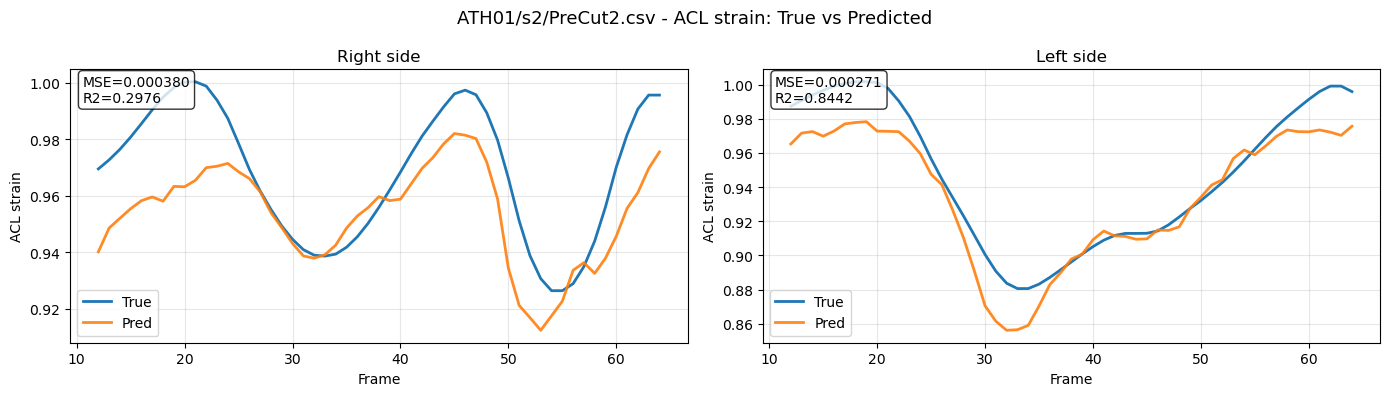

ATH03/s2/PreCut1.csv | RIGHT: MSE=0.000650, R2=0.6775 | LEFT: MSE=0.000514, R2=0.8465


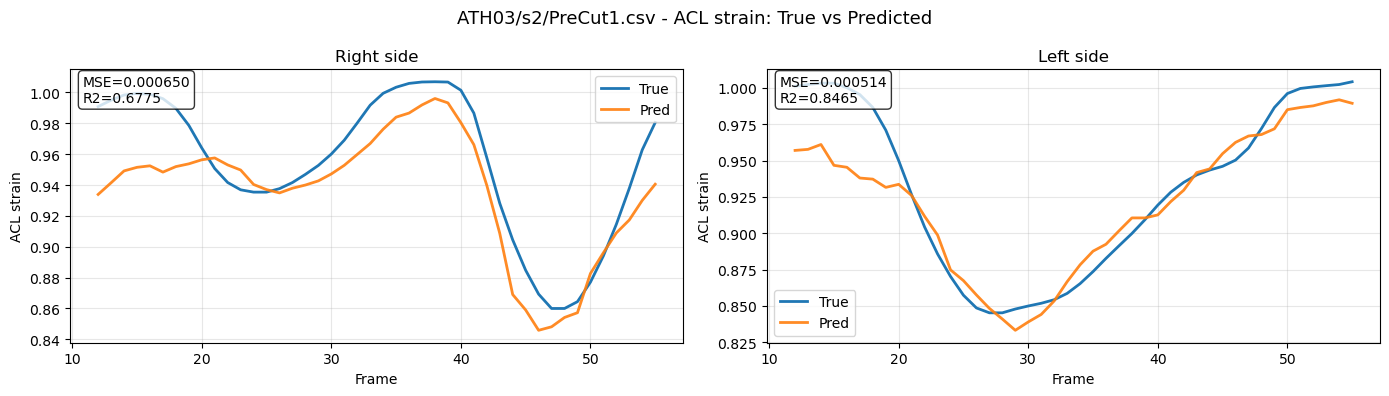

ATH03/s2/PreCut4.csv | RIGHT: MSE=0.001185, R2=0.4834 | LEFT: MSE=0.000602, R2=0.4095


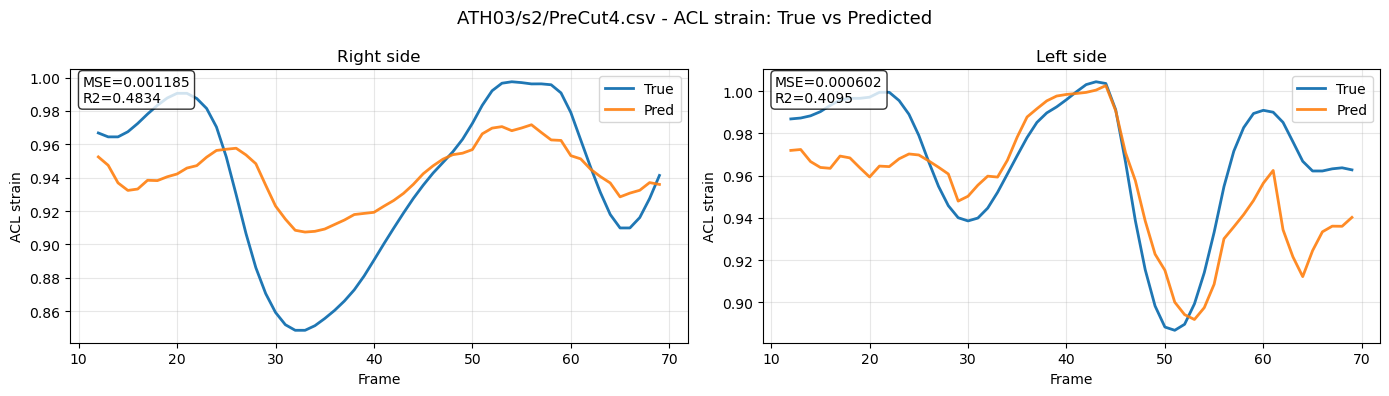

ATH04/s1/PreCut2.csv | RIGHT: MSE=0.000995, R2=0.1828 | LEFT: MSE=0.000271, R2=0.8688


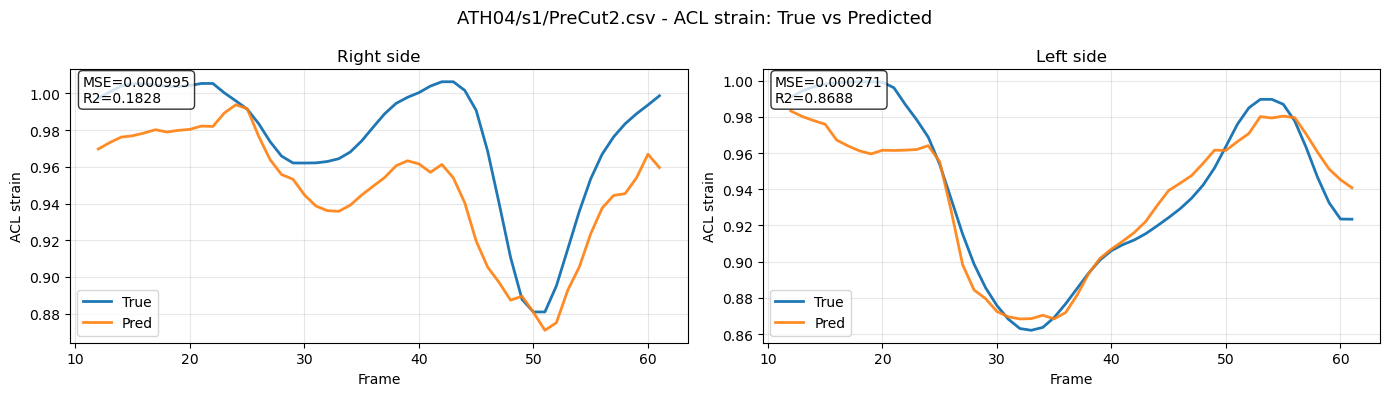

ATH04/s1/PreCut5.csv | RIGHT: MSE=0.001252, R2=-0.2703 | LEFT: MSE=0.000763, R2=0.7524


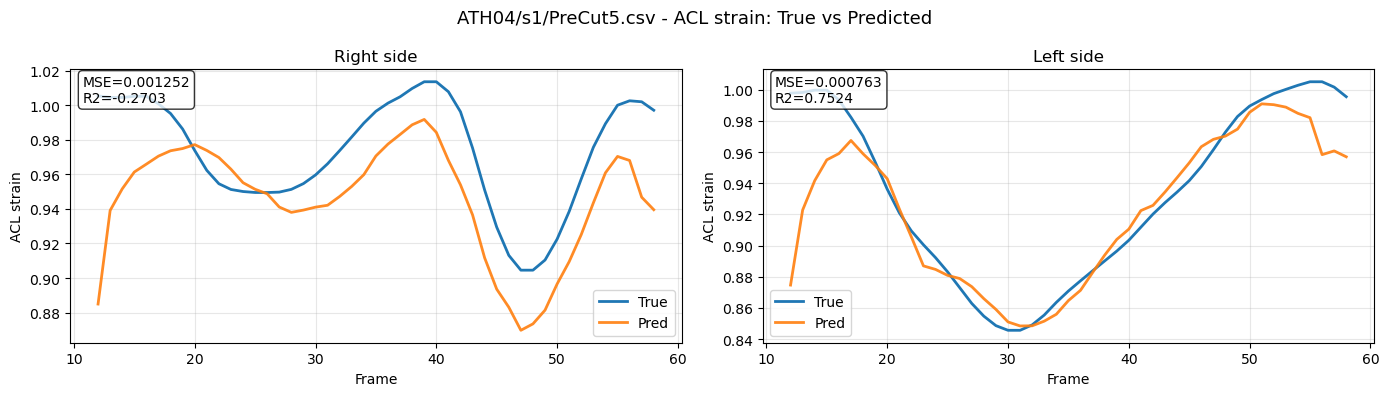

ATH05/s2/PreCut5.csv | RIGHT: MSE=0.001370, R2=0.2861 | LEFT: MSE=0.001530, R2=0.1372


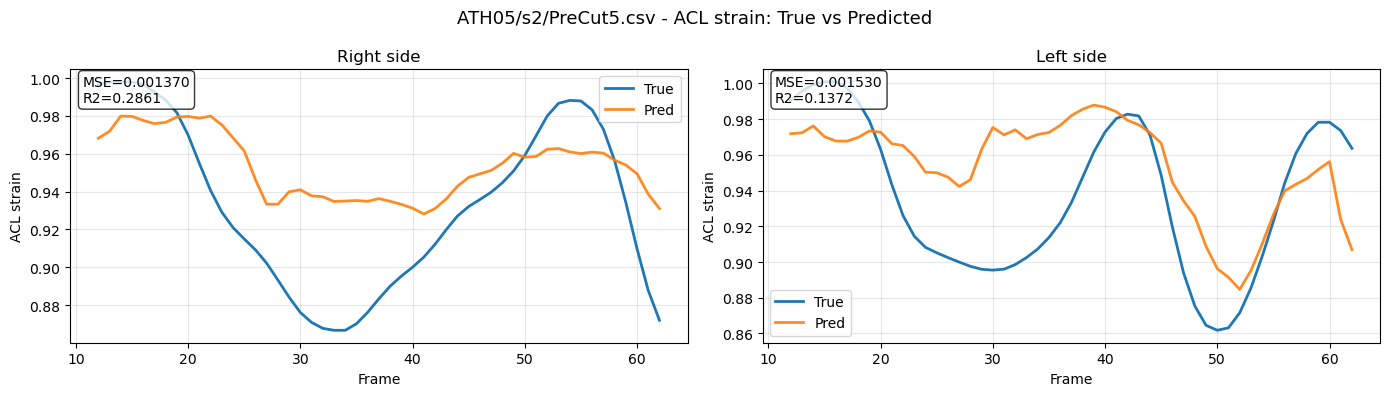

ATH06/s1/PreCut3.csv | RIGHT: MSE=0.001133, R2=0.3970 | LEFT: MSE=0.000416, R2=0.7800


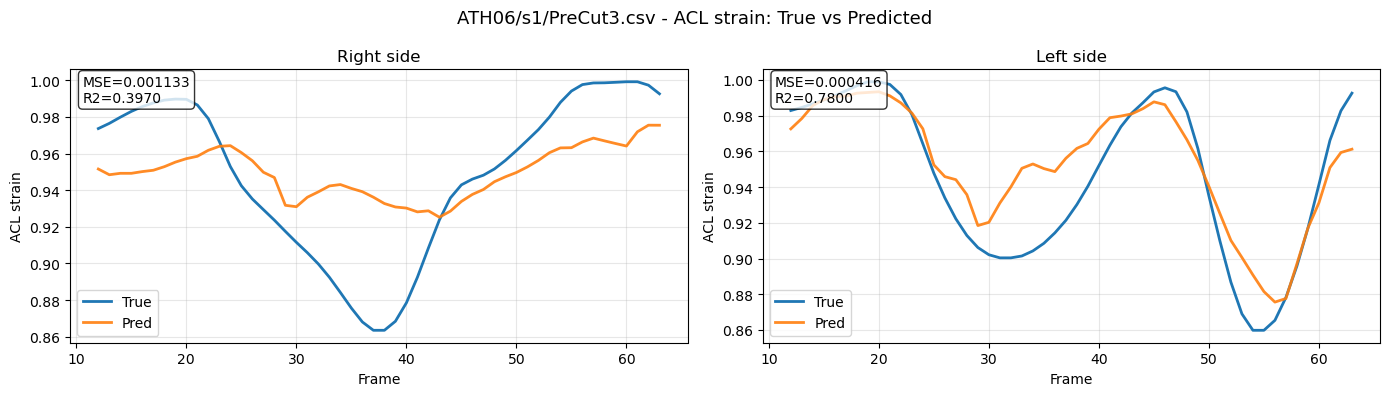

ATH06/s1/PreCut5.csv | RIGHT: MSE=0.000551, R2=0.5124 | LEFT: MSE=0.000335, R2=0.7302


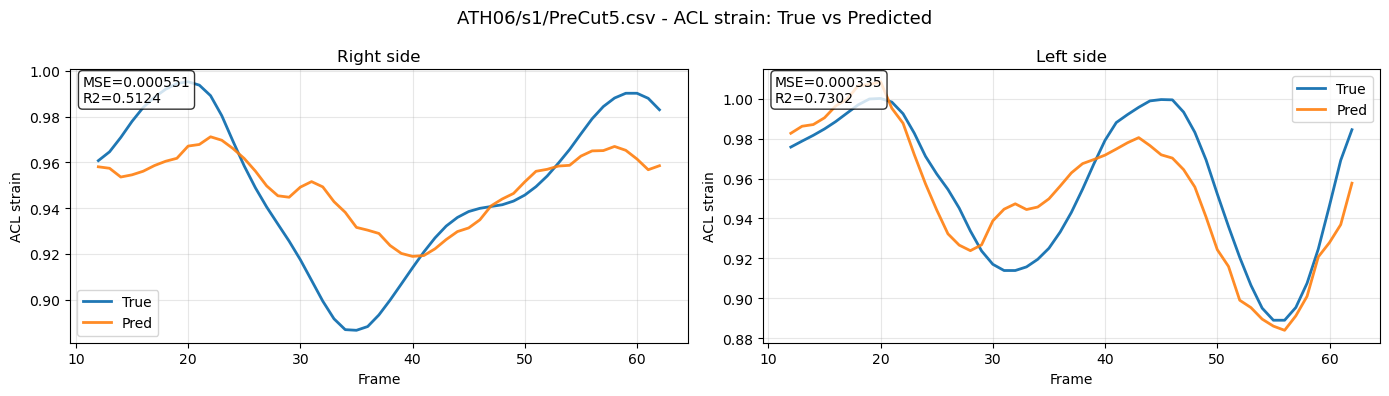

ATH06/s2/PreCut.csv | RIGHT: MSE=0.007286, R2=-0.2547 | LEFT: MSE=0.000820, R2=0.1642


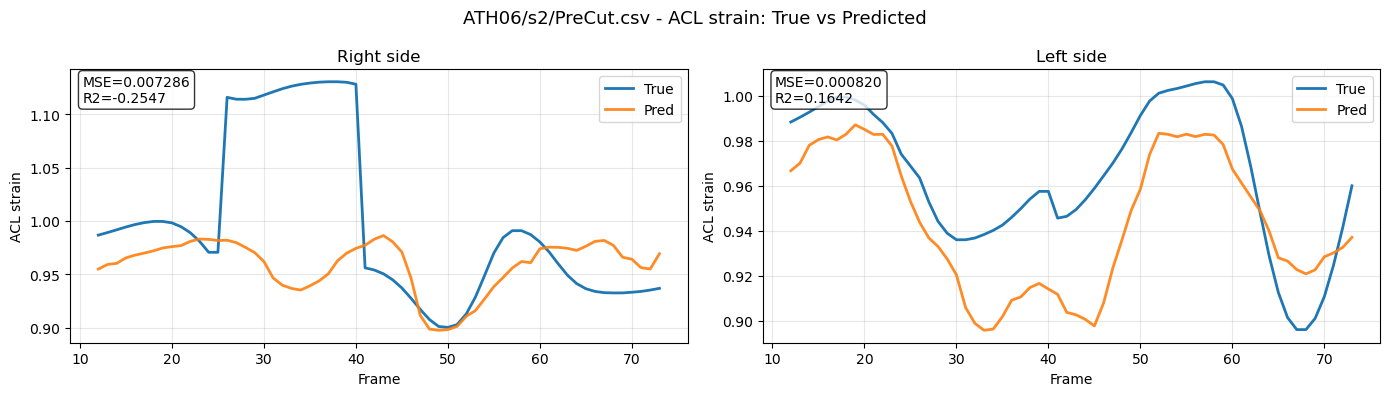

ATH06/s2/PreCut5.csv | RIGHT: MSE=0.000263, R2=0.7672 | LEFT: MSE=0.000391, R2=0.5116


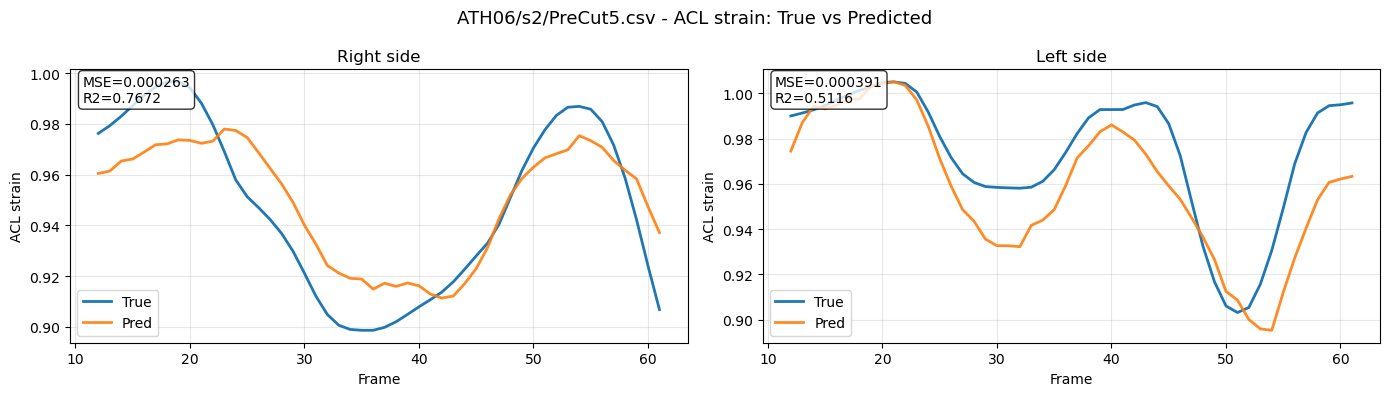

ATH07/s1/PreCut2.csv | RIGHT: MSE=0.001146, R2=0.2258 | LEFT: MSE=0.000227, R2=0.8844


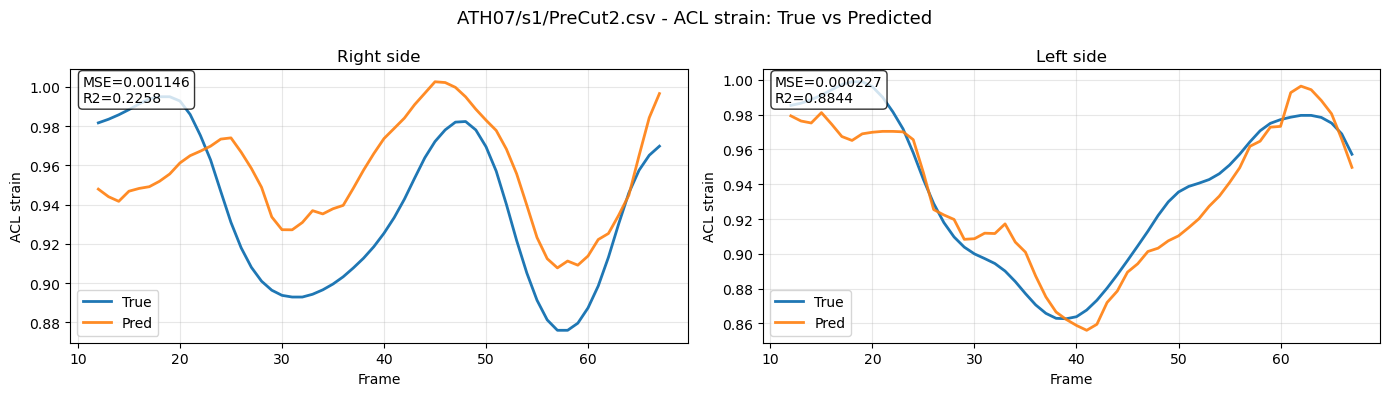

ATH07/s2/PreCut.csv | RIGHT: MSE=0.000354, R2=0.7355 | LEFT: MSE=0.000195, R2=0.8380


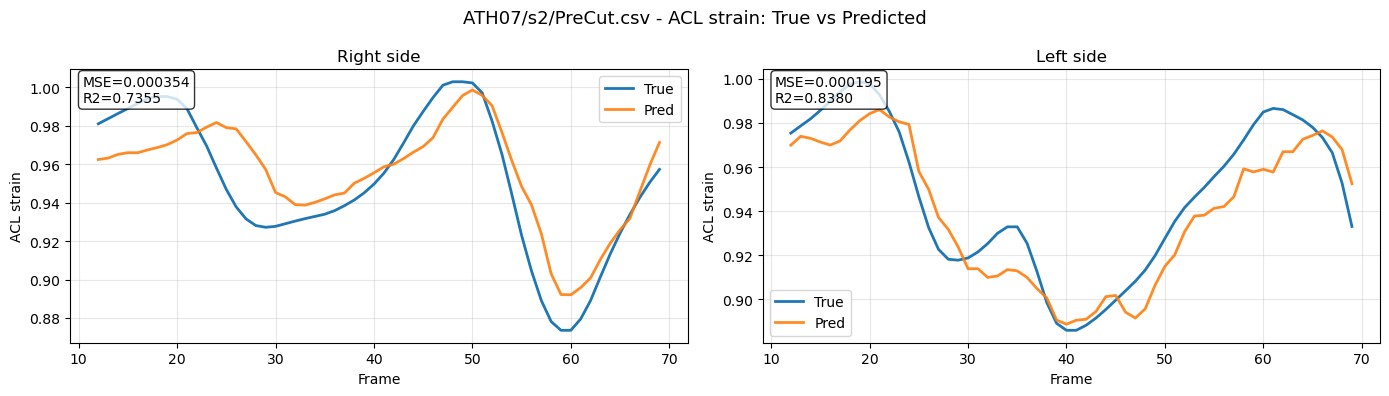

ATH07/s2/PreCut3.csv | RIGHT: MSE=0.001517, R2=0.2736 | LEFT: MSE=0.000565, R2=0.5130


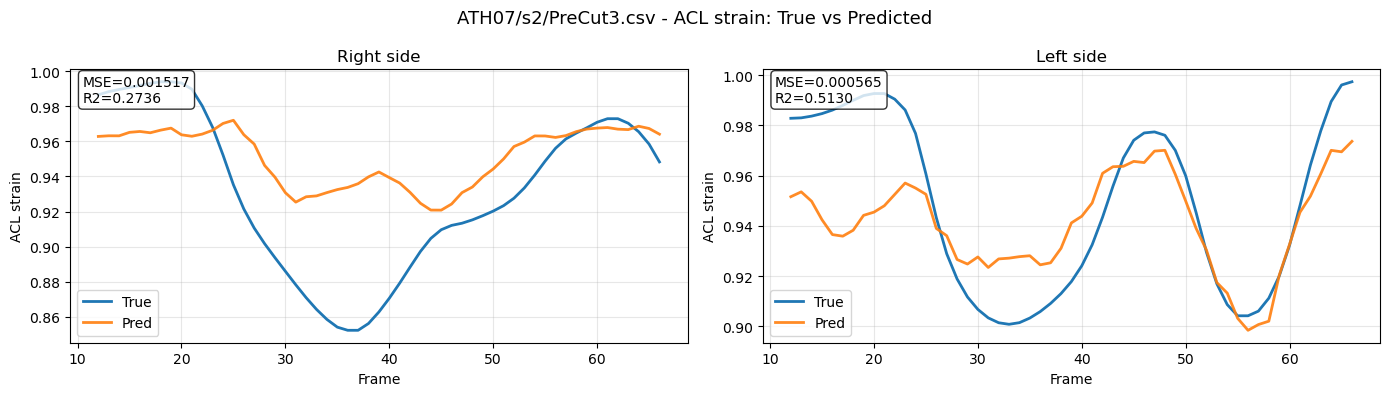

ATH09/s1/PreCut.csv | RIGHT: MSE=0.000455, R2=0.6316 | LEFT: MSE=0.000529, R2=0.7354


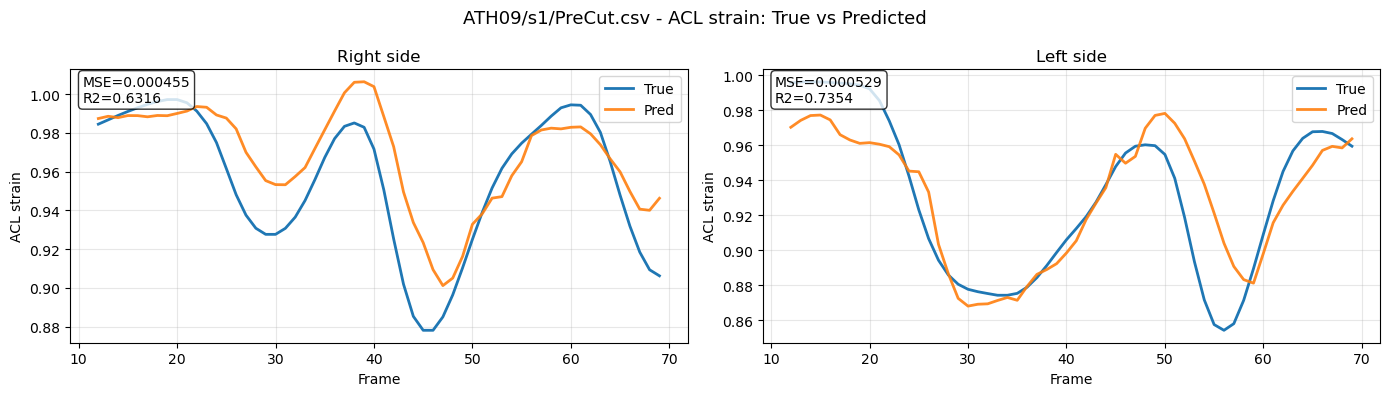

ATH09/s2/PreCut4.csv | RIGHT: MSE=0.002283, R2=-0.1790 | LEFT: MSE=0.011239, R2=-0.8812


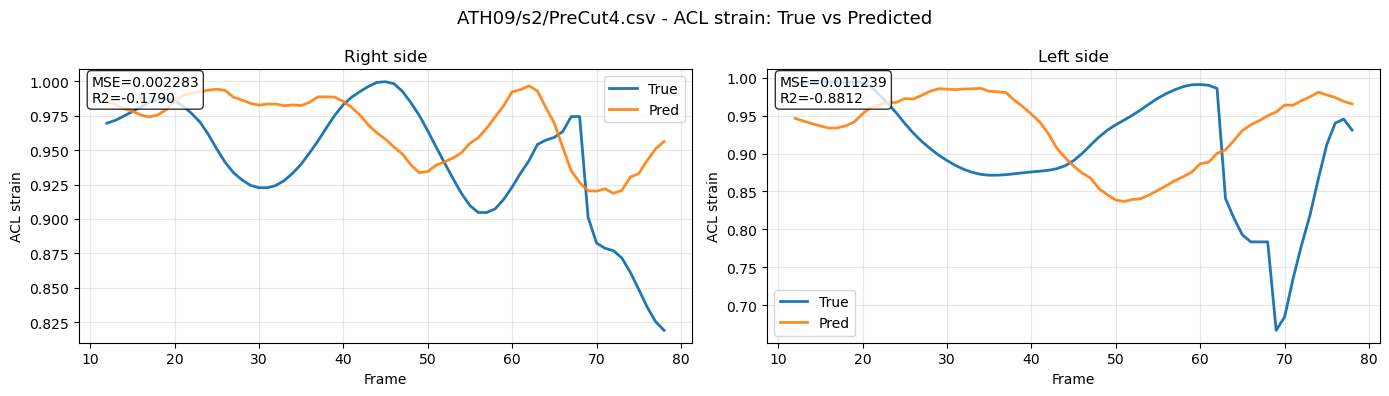

ATH11/s1/PreCut1.csv | RIGHT: MSE=0.007664, R2=-1.4161 | LEFT: MSE=0.002179, R2=-0.0374


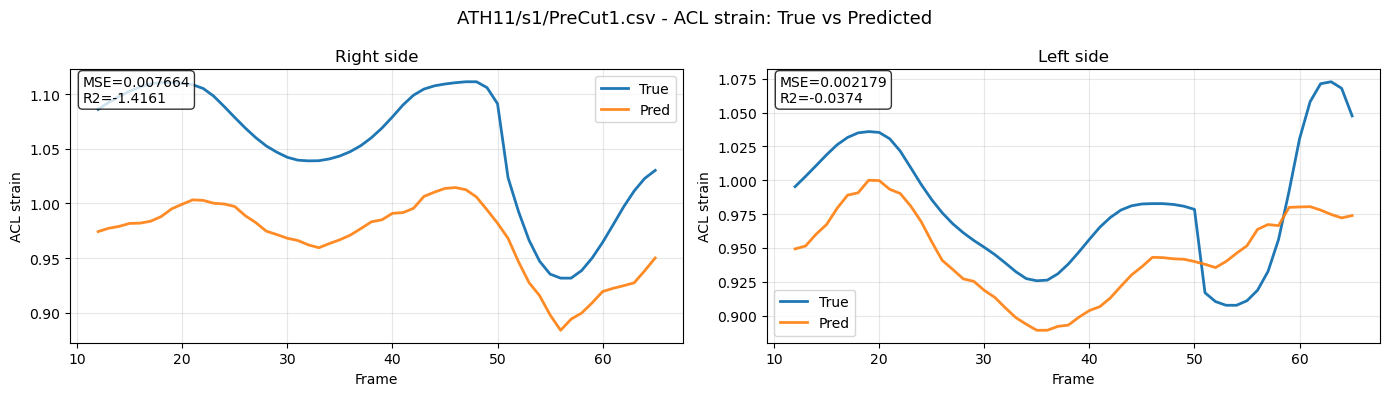

ATH13/s2/PreCut1.csv | RIGHT: MSE=0.000529, R2=0.8617 | LEFT: MSE=0.000509, R2=0.7999


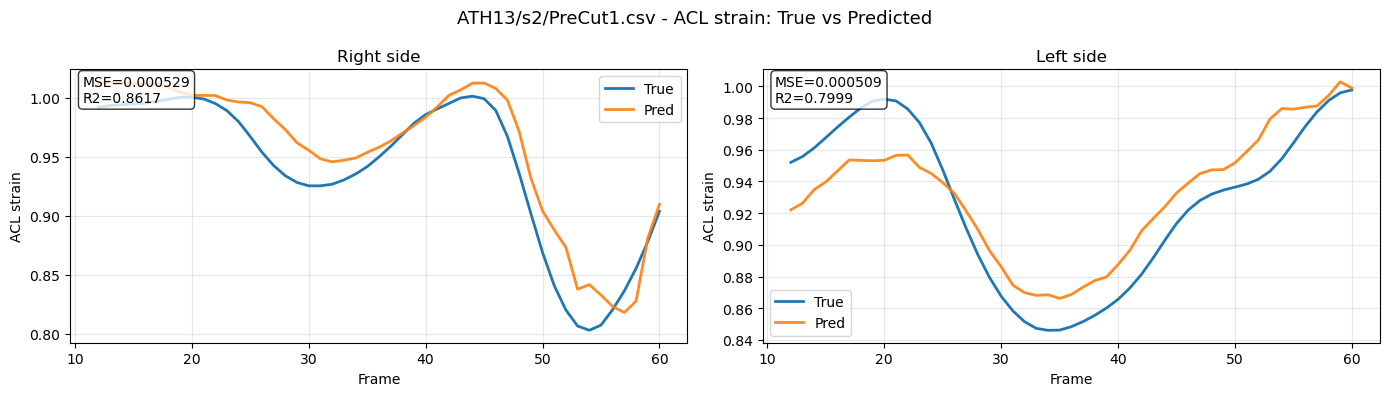

ATH14/s1/PreCut2.csv | RIGHT: MSE=0.002045, R2=-0.3469 | LEFT: MSE=0.000409, R2=0.6833


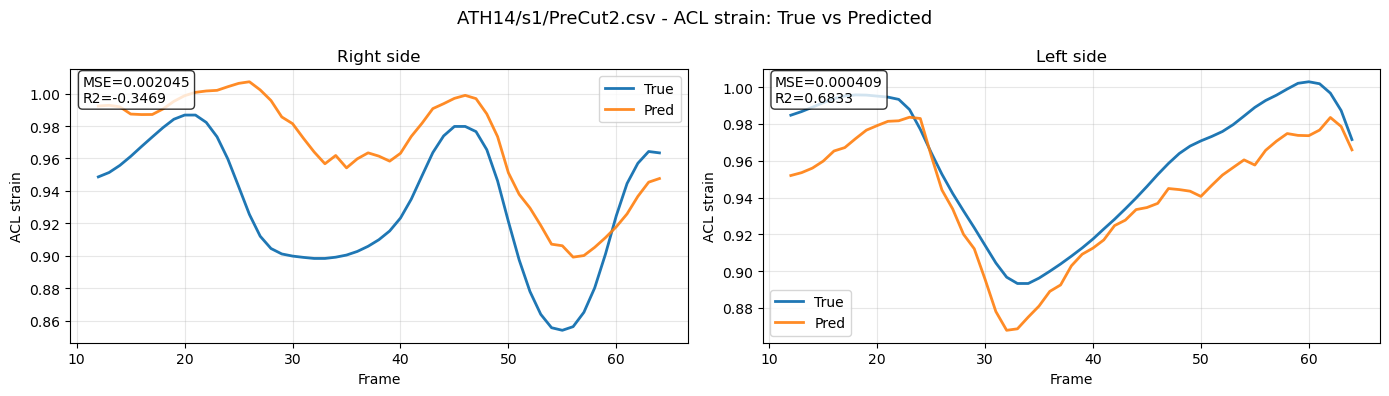

ATH15/s1/PreCut.csv | RIGHT: MSE=0.000955, R2=-0.1220 | LEFT: MSE=0.000531, R2=0.7959


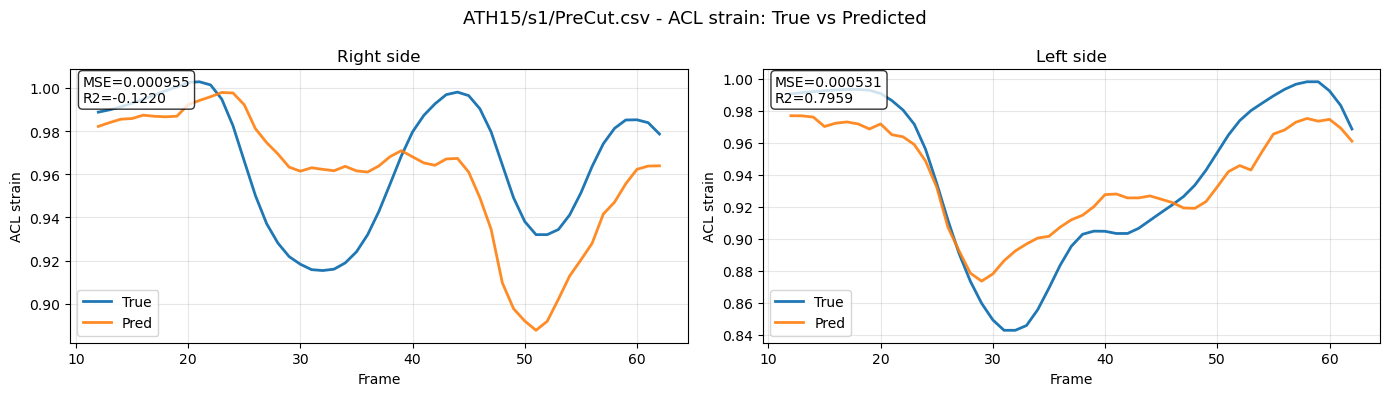

ATH15/s1/PreCut3.csv | RIGHT: MSE=0.001175, R2=0.3941 | LEFT: MSE=0.000138, R2=0.9363


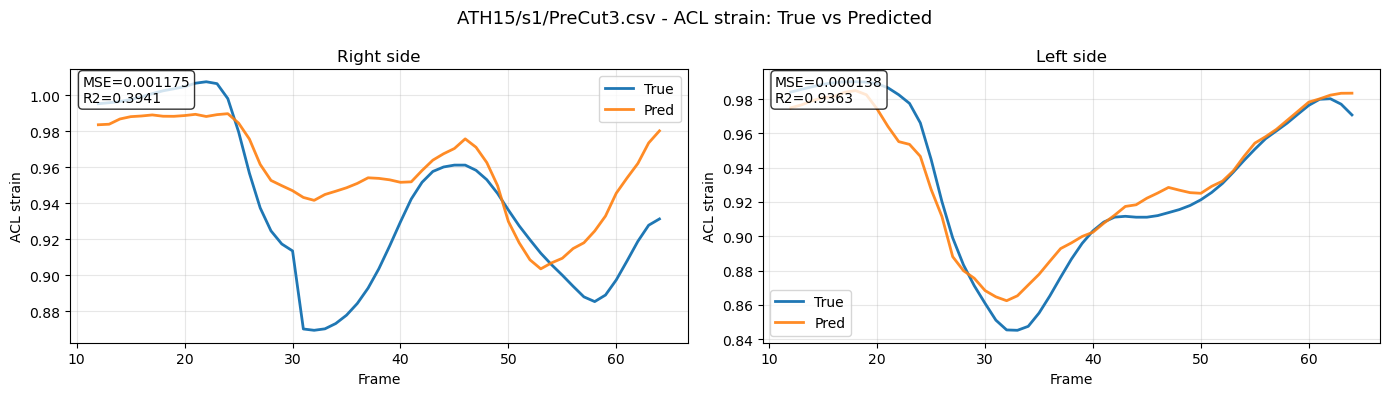

ATH17/s2/PreCut4.csv | RIGHT: MSE=0.008902, R2=-5.5175 | LEFT: MSE=0.007960, R2=-0.3662


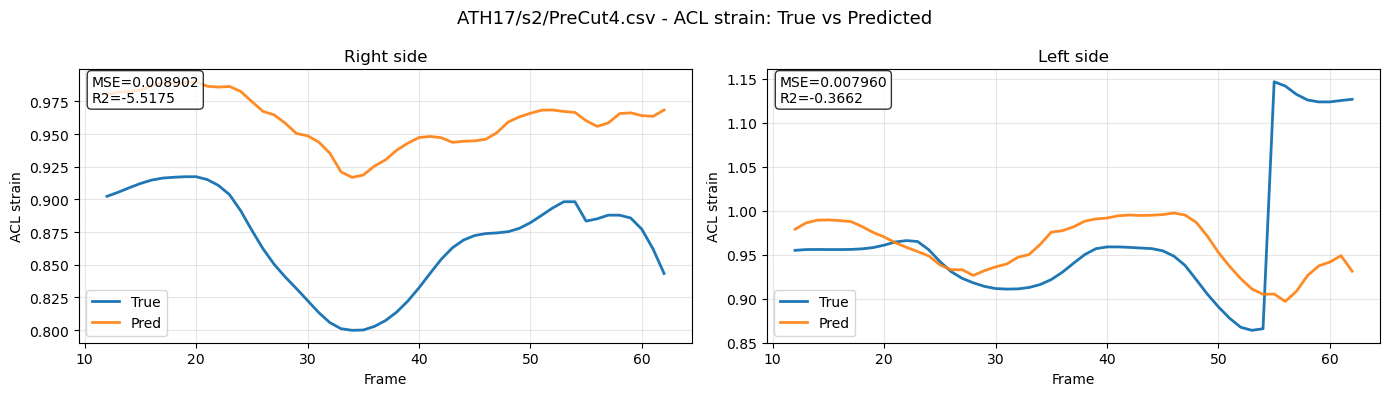

ATH18/s1/PreCut1.csv | RIGHT: MSE=0.009334, R2=-4.8411 | LEFT: MSE=0.000543, R2=0.5886


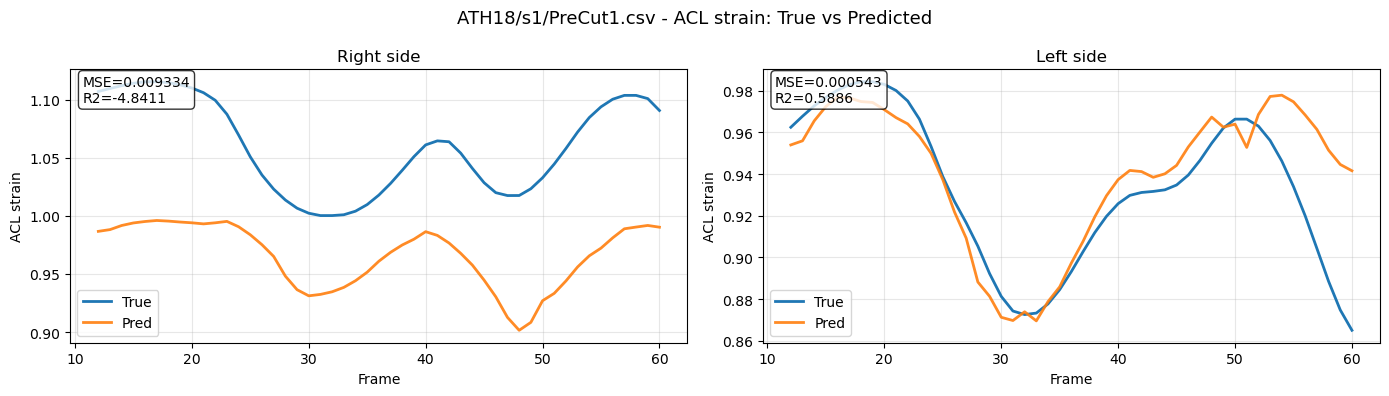

ATH18/s1/PreCut2.csv | RIGHT: MSE=0.000159, R2=0.7737 | LEFT: MSE=0.000933, R2=-0.2612


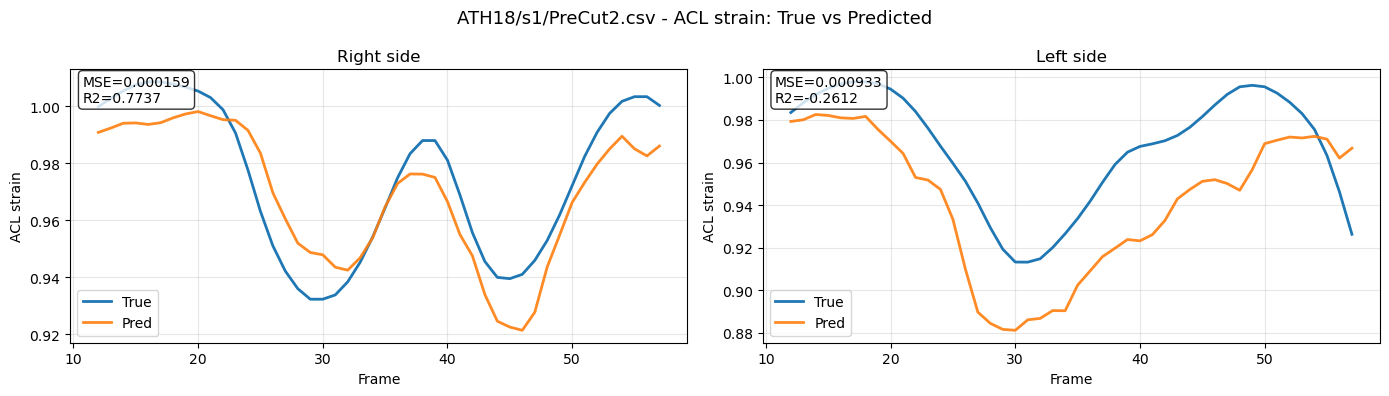

ATH18/s1/PreCut3.csv | RIGHT: MSE=0.001339, R2=0.4450 | LEFT: MSE=0.000968, R2=-0.5120


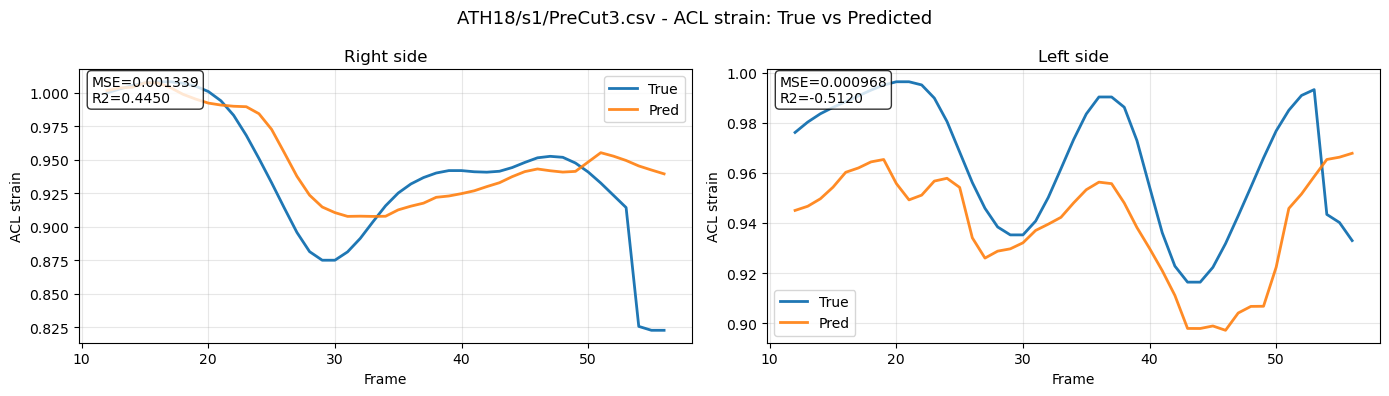

ATH21/s2/PreCut2.csv | RIGHT: MSE=0.000201, R2=0.4724 | LEFT: MSE=0.000657, R2=0.4600


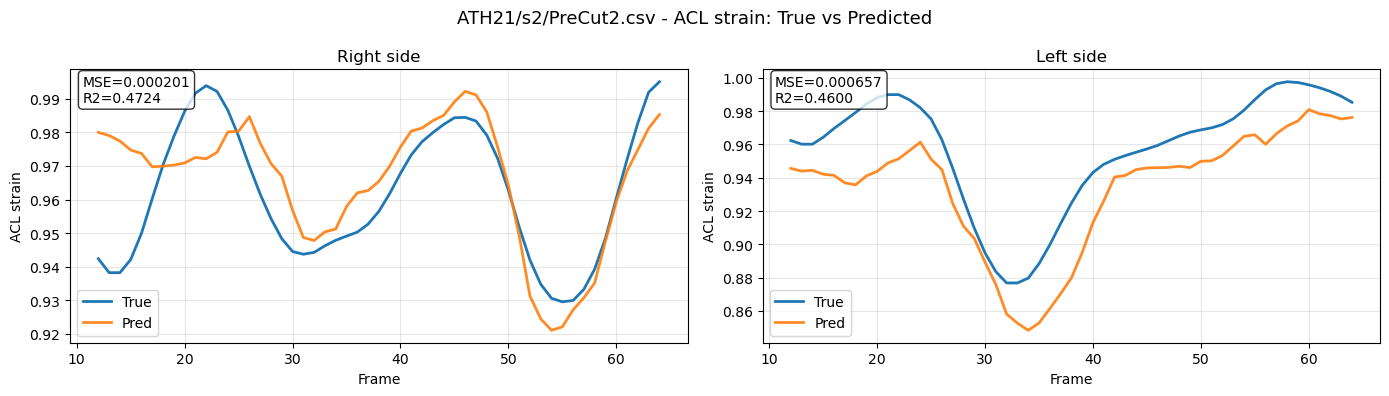

ATH22/s2/PreCut2.csv | RIGHT: MSE=0.008110, R2=-6.7640 | LEFT: MSE=0.000508, R2=0.6356


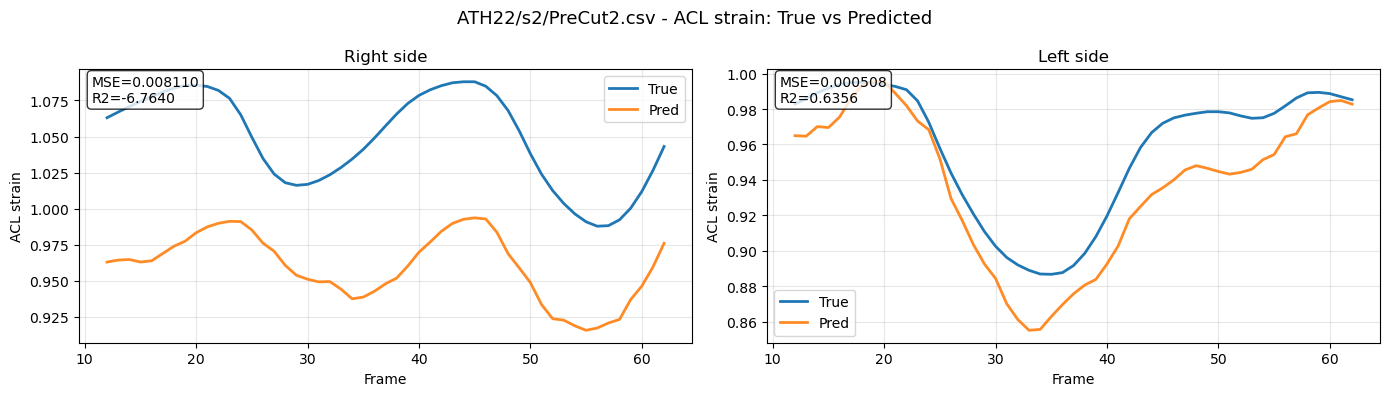

ATH23/s1/PreCut1.csv | RIGHT: MSE=0.005778, R2=-0.6721 | LEFT: MSE=0.004653, R2=-2.0936


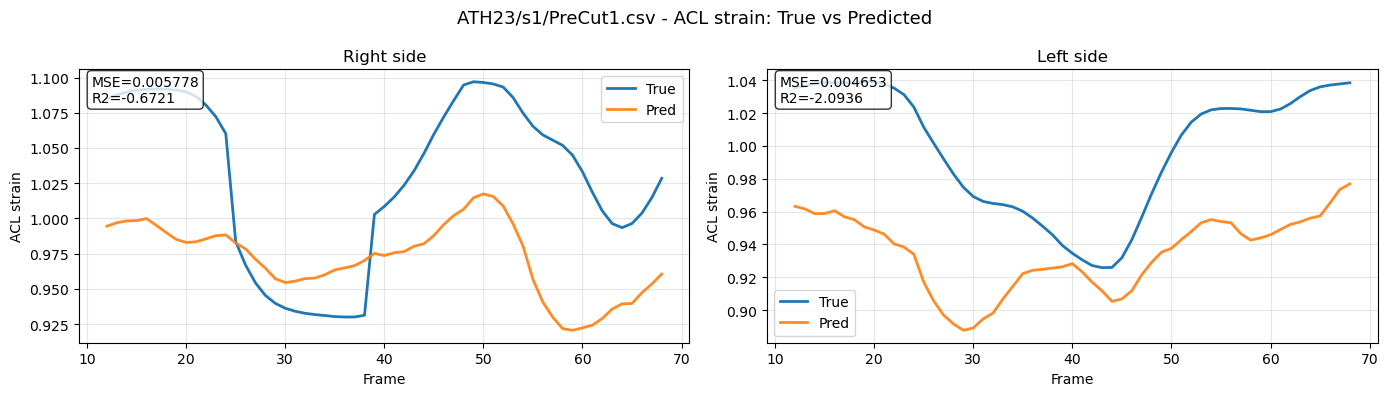

ATH23/s1/PreCut2.csv | RIGHT: MSE=0.006779, R2=-1.0750 | LEFT: MSE=0.007649, R2=-16.2663


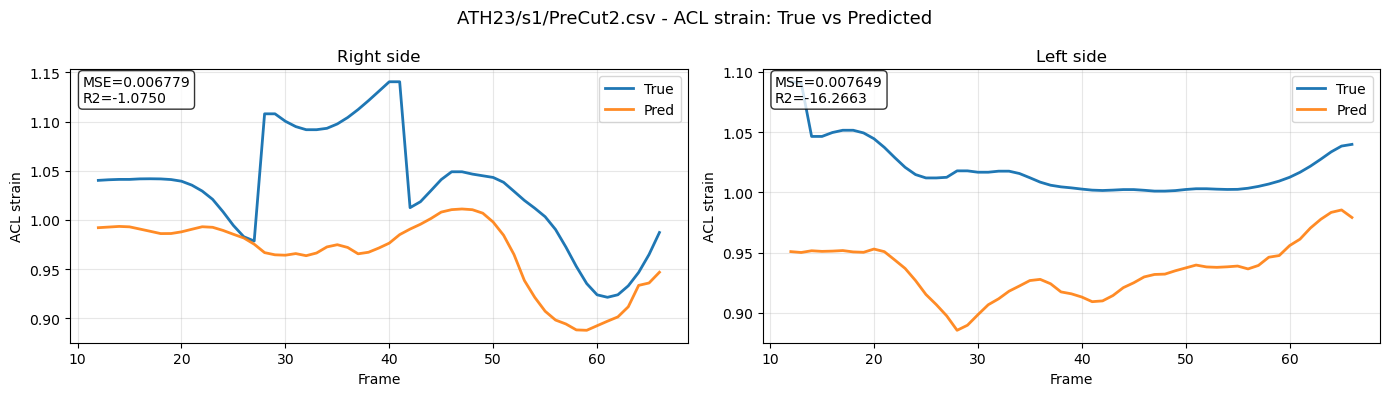

ATH24/s2/PreCut4.csv | RIGHT: MSE=0.005827, R2=-0.4282 | LEFT: MSE=0.003388, R2=-3.3667


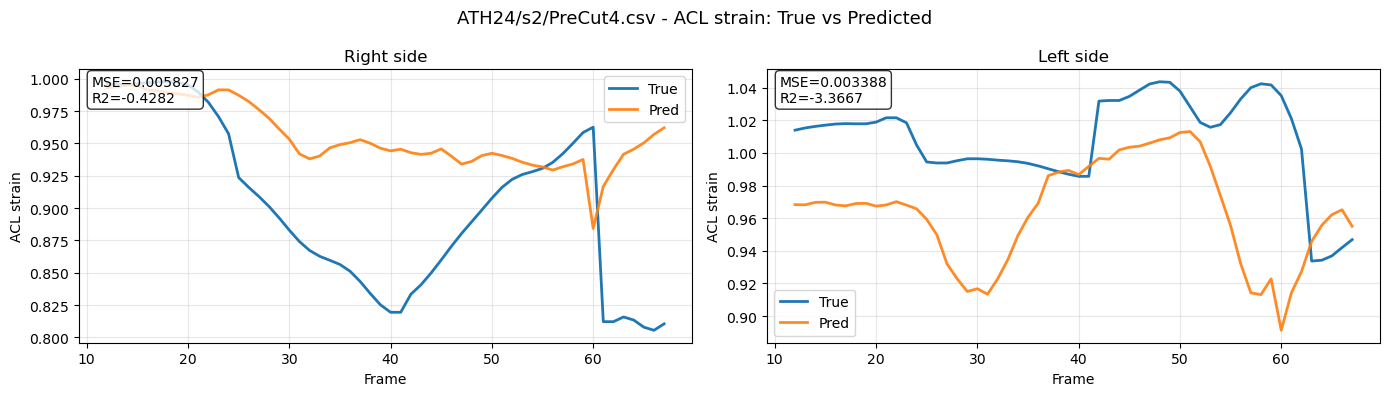

ATH25/s2/PreCut3.csv | RIGHT: MSE=0.000359, R2=0.2617 | LEFT: MSE=0.000634, R2=0.6201


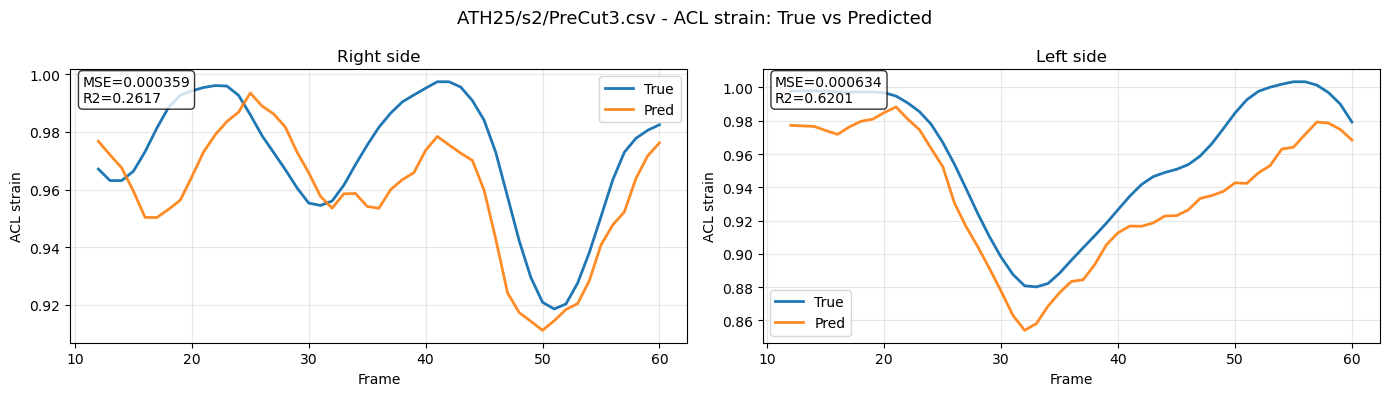

In [2]:
# Plot true vs predicted ACL strain over frame for each test video + per-video metrics (MSE, R2).
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

pred_csv = (SAVE_DIR / "bilstm_bis_test_predictions.csv") if "SAVE_DIR" in globals() else Path("saved_models/bilstm_bis_test_predictions.csv")
df_plot = pd.read_csv(pred_csv)
df_plot = df_plot.sort_values(["video_name", "frame_idx"]).reset_index(drop=True)

required_cols = [
    "video_name",
    "frame_idx",
    "RIGHT_ACL_STRAIN_true",
    "RIGHT_ACL_STRAIN_pred",
    "LEFT_ACL_STRAIN_true",
    "LEFT_ACL_STRAIN_pred",
]
missing_cols = [c for c in required_cols if c not in df_plot.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns in {pred_csv}: {missing_cols}")

print(f"Loaded {len(df_plot):,} rows across {df_plot['video_name'].nunique()} test videos from {pred_csv}\n")

for video_name, g in df_plot.groupby("video_name", sort=True):
    g = g.sort_values("frame_idx")

    # Per-video, per-side metrics
    mse_right = mean_squared_error(g["RIGHT_ACL_STRAIN_true"], g["RIGHT_ACL_STRAIN_pred"])
    r2_right = r2_score(g["RIGHT_ACL_STRAIN_true"], g["RIGHT_ACL_STRAIN_pred"])
    mse_left = mean_squared_error(g["LEFT_ACL_STRAIN_true"], g["LEFT_ACL_STRAIN_pred"])
    r2_left = r2_score(g["LEFT_ACL_STRAIN_true"], g["LEFT_ACL_STRAIN_pred"])

    print(
        f"{video_name} | RIGHT: MSE={mse_right:.6f}, R2={r2_right:.4f} | "
        f"LEFT: MSE={mse_left:.6f}, R2={r2_left:.4f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
    fig.suptitle(f"{video_name} - ACL strain: True vs Predicted", fontsize=13)

    axes[0].plot(g["frame_idx"], g["RIGHT_ACL_STRAIN_true"], label="True", linewidth=2)
    axes[0].plot(g["frame_idx"], g["RIGHT_ACL_STRAIN_pred"], label="Pred", linewidth=2, alpha=0.9)
    axes[0].set_title("Right side")
    axes[0].set_xlabel("Frame")
    axes[0].set_ylabel("ACL strain")
    axes[0].grid(alpha=0.3)
    axes[0].legend()
    axes[0].text(
        0.02, 0.98,
        f"MSE={mse_right:.6f}\nR2={r2_right:.4f}",
        transform=axes[0].transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    axes[1].plot(g["frame_idx"], g["LEFT_ACL_STRAIN_true"], label="True", linewidth=2)
    axes[1].plot(g["frame_idx"], g["LEFT_ACL_STRAIN_pred"], label="Pred", linewidth=2, alpha=0.9)
    axes[1].set_title("Left side")
    axes[1].set_xlabel("Frame")
    axes[1].set_ylabel("ACL strain")
    axes[1].grid(alpha=0.3)
    axes[1].legend()
    axes[1].text(
        0.02, 0.98,
        f"MSE={mse_left:.6f}\nR2={r2_left:.4f}",
        transform=axes[1].transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    plt.tight_layout()
    plt.show()